## Práctica 1: Redución da Dimensionalidade

Nesta primeira práctica imonos centrar no funcionamento e posibilidades que nos ofrecen as técnicas de reducción da dimensionalidade. Estas técnicas son de especial utilidade para a **visualización** da estructura interna dos datos e a obtención de **representacións compactas** que compriman e conserven a maior parte da información relevante (*embeddings*). O que nos permite entender os nosos datos e mellorar o rendemento dos modelos, ao evitar o sobreaxuste e reducir o seu custo computacional. Durante este guión aprenderemos sobre as técnicas de:
- PCA
- t-SNE
- UMAP

detendonos nas súas debilidades e fortalezas e facendo unha comparativa entre elas.

---

**Asignatura:** Aprendizaxe Automática Non Supervisada --- *Universidade de Santiago de Compostela*

**Profesor:** Noel Suárez Barro

**Email:** noel.suarez.barro@usc.es

**Curso:** 2024-2025

---

*Entrega de*:

<center><h3>Lucas Andrea Martínez Calveiro</h3></center>

## Instrucións da práctica

Ao igual que no resto de prácticas da asignatura, nesta sesión empregaremos un **Jupyter Notebook** que servirá como guión para a realización da práctica. 

O **Jupyter Notebook** é un arquivo *Markdown* que integra celdas de código Python, as cales deberedes completar e executar paso a paso seguindo as indicacións do enunciado.

O *notebook* execútase sobre un *kernel* de Python que garda unha **memoria das celdas executadas**. Desta forma, as funcións definidas nunha celda previamente executada poden volver a empregarse en sucesivas celdas sen necesidade de redefinila de cada vez. Pero OLLO, se nos esquecemos de executar a celda na que se define unha función e intentamos empregala máis adiante, recibiremos un erro.

Ao rematar a práctica, deberedes exportar o guión completo a formato HTML, e subilo ao campus virtual co nome ``APELIDO1_APELIDO2_NOME_ReducionDimensionalidade.html``. Lembrade tamén **indicar o voso nome na celda anterior**.

## Reproducibilidade dos resultados

Moitas das funcións que empregaremos fan uso de inicializacións mediante o uso de números aleatorios. Debido a isto, ao executar diversas veces o mesmo código, imos obter resultados diferentes, facendo bastante complicada a depuración do código.

Para evitar isto, imos fixar unha semente (*seed*) antes da execución de cada función que introduza un compoñente aleatorio, ou nos propios parámetros da función, se esta o permite. Para obter todos os mesmos resultados, imos empregar sempre o valor ``123``.

In [1]:
import numpy as np

SEED = 123
np.random.seed(SEED)

## Xestión de entornos

As librerías empregadas durante a práctica son: 

- numpy
- pandas
- scikit-learn
- matplotlib
- seaborn
- plotly
- keras
- tensorflow
- umap-learn

Se tedes problemas de compatibilidade entre librerías recomendamos a creación dun entorno de conda para xestionar as versións, seguindo os seguintes pasos:

    1. Crear e activar o entorno conda:

        conda create -n my_env python=3.8
        conda activate my_env
        
    2. Instalar as librerías necesarias:

        conda install -c conda-forge seaborn==0.13.2
        conda install keras
        conda install tensorflow
        conda install jinja2
        conda install plotly
        conda install ipykernel
        conda install nbformat
        conda install umap-learn

    3. Agrega o kernel para que poida ser empregado dende JupyterNotebook
    
        python -m ipykernel install --user --name=my_env --display-name "my_env"

    4. O kernel xa debería estar disponible para a escolla na pestana 'Kernel>Change Kernel...' de JupyterNotebook.


## Descripcións dos datasets

Antes de nada, unha pequena descripción dos datasets que empregaremos ao longo desta práctica:

- **Iris.** O dataset Iris é un dos conxuntos de datos máis coñecidos no ámbito da aprendizaxe automática. Contén información sobre tres especies de flores Iris: setosa, versicolor e virginica. O conxunto inclúe 150 exemplos (50 por especie), con catro características numéricas: o longo e o ancho dos pétalos, e o longo e o ancho dos sépalos, expresados en centímetros. É amplamente empregado en problemas de clasificación e visualización de datos debido á súa simplicidade e estrutura ben equilibrada.

- **MNIST (_digits_).** O dataset MNIST é un conxunto de datos clásico utilizado para tarefas de recoñecemento de imaxes e clasificación. Contén 70.000 imaxes en escala de grises de díxitos escritos a man (0-9), cada unha representada nunha cuadrícula de 28x28 píxeles. Está dividido en 60.000 imaxes de adestramento e 10.000 de probas. É amplamente utilizado para aprender e avaliar modelos básicos de redes neuronais e outros algoritmos de clasificación.

- **Fashion-MNIST (_fmnist_).** O dataset Fashion-MNIST é unha alternativa máis complexa ao MNIST clásico. Contén 70.000 imaxes en escala de grises de 28x28 píxeles que representan pezas de roupa e accesorios divididos en 10 categorías, como camisetas, zapatos, pantalóns ou bolsos. Este conxunto é frecuentemente utilizado para probar modelos de aprendizaxe automática en tarefas de recoñecemento de imaxes máis desafiantes que o MNIST orixinal, mantendo unha estrutura similar.

Para maior facilidade e uniformidade empregaremos as seguintes funcións para cargalos cun formato único (un DataFrame de pandas que conten tantas columnas como características + unha columna `target` representando a etiqueta codificada e outra `label` que representa a etiqueta ou clase correspondente ao valor de target).

In [2]:
import numpy as np
import pandas as pd
from sklearn import datasets
from keras.datasets import fashion_mnist, mnist

def load_iris():
    iris = datasets.load_iris()
    iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
    
    iris_df['target'] = iris.target
    iris_df['label'] = iris_df['target'].map(dict(zip(range(len(iris.target_names)), iris.target_names)))
    return iris_df

def load_mnist():
    (x_train, y_train), (x_test, y_test) = mnist.load_data()
    X_train = np.reshape(x_train, (x_train.shape[0], -1)).astype(np.float32)
    X_test = np.reshape(x_test, (x_test.shape[0], -1)).astype(np.float32)
    data = np.concatenate((X_train, X_test), 0)
    labels = np.concatenate((y_train, y_test))
    df = pd.DataFrame(data)
    df['target'] = labels
    df['label'] = labels
    return df

def load_fmnist():
    (x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
    X_train = np.reshape(x_train, (x_train.shape[0], -1)).astype(np.float32)
    X_test = np.reshape(x_test, (x_test.shape[0], -1)).astype(np.float32)
    data = np.concatenate((X_train, X_test), 0)
    labels = np.concatenate((y_train, y_test))
    df = pd.DataFrame(data)
    df['target'] = labels
    class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                   'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
    df['label'] = df['target'].map(dict(zip(range(len(class_names)), class_names)))
    return df

## Parte 1: achegamento inicial con Iris 

### 1.1 Análise exploratoria

Empezemos analizando o dataset Iris. Este dataset conta coas medidas de lonxitude e anchura dos pétalos e sépalos para varios espécimens de distintas especies de flores de iris , a saber: _Iris setosa_, _Iris versicolor_, e _Iris virginica_. 

In [3]:
iris = load_iris()
iris

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,label
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


![](https://tutkukaya.com/wp-content/uploads/2023/11/iris-machinelearning-1024x383.png)

Como este dataset ten poucas características, comezaremos facendo unha visualización global da distribución das mesmas, comparandoas dous a dous parar ver as súas relacións (sen empregar ainda ningunha técnica de reducción da dimensionalidade).

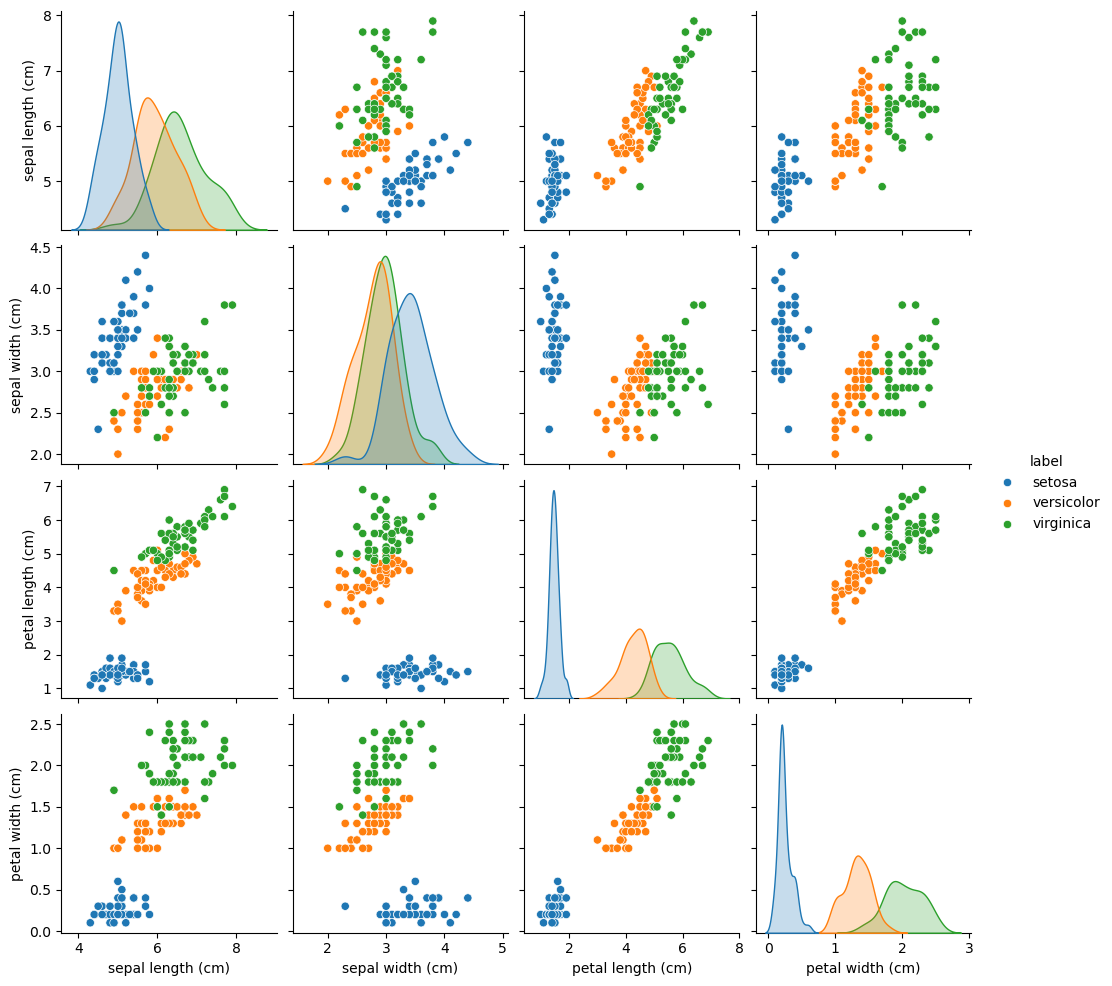

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

_ = sns.pairplot(iris.drop(columns=['target']), hue='label')

**Pregunta 1. A vista das gráficas anteriores, cales dirías que son as variables máis representativas da especie?**

Basándome en la diagonal (las distribuciones de densidad) diría que las variables más representativas de la especie son las referentes al pétalo. Tanto en petal length como en petal width vemos una diferenciación más marcada entre las 3 especies, sobre todo la clase setosa.

**Pregunta 2. Cal é o número total de compoñentes que esperamos obter se non fixamos o parámetro `n_components` da función `PCA`? Por que? Que representa cada unha destas compoñentes?**

Obtendríamos tantas componentes como variables originales tiene el dataset, en este caso 4. Esto se debe a que la función PCA, por defecto, obtiene el mismo número de componentes que variables originales (siempre que el número de muestras sea mayor que el de variables). 

Cada componente principal en PCA es una combinación lineal de las variables originales. La primera componente representa la dirección en el espacio de 4 dimensiones a lo largo de la cual los datos están más dispersos (tienen mayor varianza). La segunda componente representa la segunda dirección con más varianza, con la condición de que debe ser ortogonal a PC1, asegurando que la información captada sea nueva. El resto de componentes siguen esta lógica pero suelen aportar poca varianza (se suele ver una especie de codo).

### 1.2 Entendendo PCA

Agora sí, fagamos un primeiro exemplo do uso de PCA sobre este dataset:

In [5]:
from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(iris.drop(columns=['target', 'label']))  ## prescindimos das columnas target/label (aprendizaxe non supervisado)

Botemos un ollo ás compoñentes extraídas e a contribución das características orixinais a cada unha delas:

In [6]:
from matplotlib import colormaps

components_df = pd.DataFrame(pca.components_, columns=iris.drop(columns=['target', 'label']).columns)

components_df.index.name = 'PCA Component'

def paint_rows(val):
    norm = plt.Normalize(vmin=-1, vmax=1)
    c = colormaps['coolwarm'](norm(val))
    rgb = tuple(int(c * 255) for c in c[:3])
    color = 'background-color: {}'.format(f'rgba({rgb[0]}, {rgb[1]}, {rgb[2]}, 1)')
    return color

# Aplicar la función de estilización al DataFrame
styled_df = components_df.style.applymap(paint_rows)
styled_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
PCA Component,,,,
0,0.361387,-0.084523,0.856671,0.358289
1,0.656589,0.730161,-0.173373,-0.075481
2,-0.582030,0.597911,0.076236,0.545831
3,-0.315487,0.319723,0.479839,-0.753657


**Pregunta 3. Que variables teñen un maior impacto nas primeras compoñentes? Concorda ca análise realizada anteriormente?**

La primera componente esta afectada principalmente por petal length aunque tambien aparecen sepal length y petal width en igual medida. Podría indicar simplemente flores de gran tamaño y es perfecta para distinguir a la flor Setosa. La segunda componente está afectada principalmente por el tamaño del sépalo, tanto sepal width como sepal length.

Esto concuerda con el análisis anterior puesto que la variable más importante de la primera componente (la que más varianza explica) es el petal length. Podría parecer extraño que se le da tan poca importancia al petal width pero esto se explica por la alta correlación que tiene con petal length sumada al menor rango de variabilidad que representa.

In [7]:
# Varianza explicada por cada componente
explained_variance = pca.explained_variance_ratio_
explained_variance

array([0.92461872, 0.05306648, 0.01710261, 0.00521218])

**Pregunta 4. Cal é a porcentaxe total da varianza orixinal que explican as dúas primeiras compoñentes? E as tres primeiras?**

In [8]:
explained_variance_cumulative = np.cumsum(explained_variance)
explained_variance_cumulative

array([0.92461872, 0.97768521, 0.99478782, 1.        ])

Las dos primeras un 97.77% y las tres primeras un 99.48%.

### 1.3. Visualización

Visualicemos agora como quedarían distribuidos os datos no espazo atendendo únicamente as duas primeras compoñentes:

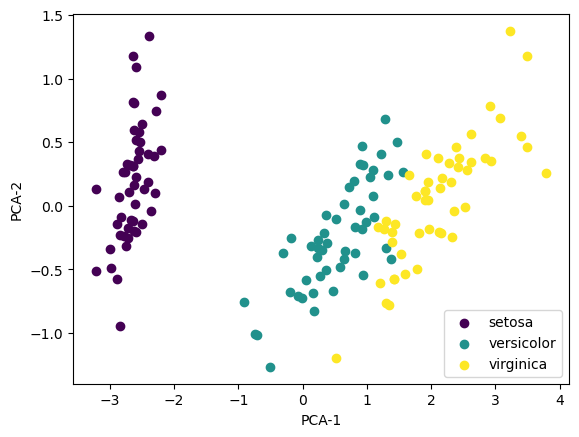

In [9]:
sns.set_palette(colormaps['viridis'](np.linspace(0, 1, iris['label'].nunique())))
    
for label in iris['label'].unique():
    select = iris.label == label
    plt.scatter(X_pca[select, 0], X_pca[select, 1], label=label)

plt.xlabel('PCA-1')
plt.ylabel('PCA-2')
plt.legend()

plt.show()

Tamén poderiamos visualizar as tres primeiras compoñentes de PCA, facendo uso das 3 dimensións. 

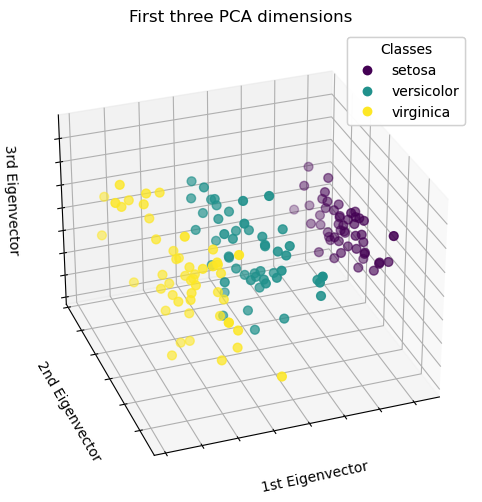

In [10]:
fig = plt.figure(1, figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)

scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
    c=iris.target,
    s=40,
)

ax.set(
    title="First three PCA dimensions",
    xlabel="1st Eigenvector",
    ylabel="2nd Eigenvector",
    zlabel="3rd Eigenvector",
)
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])

# Add a legend
legend1 = ax.legend(
    scatter.legend_elements()[0],
    iris.label.unique(),
    loc="upper right",
    title="Classes",
)
ax.add_artist(legend1)

plt.show()

Como ben sabedes, non podemos visualizar variables máis alá das tres dimensións, polo que non poderiamos graficar a cuarta compoñente. Sen embargo, neste caso, tampouco sería necesario: pois con ela estariamos a capturar o 100% da varianza dos datos orixinais (tan so tiñamos 4 características no dataset) polo que a información sería equivalente á contida no `pairplot` inicial.

En casos nos que a dimensionalidade orixinal dos datos sexa moi elevada, a graficaxe do `pairplot` sería impracticable, polo que visualizar a información contida polas 2 ou 3 compoñentes principais pode axudarnos a facernos unha idea da estructura global dos nosos datos.

Vamos a probar agora a visualizar os mesmos datos con outro algoritmo de reducción da dimensionalidade: t-SNE.

In [11]:
from sklearn.manifold import TSNE

X_tsne = TSNE(n_components=2, verbose=1, random_state=SEED, perplexity=10).fit_transform(iris.drop(columns=['target', 'label']))

[t-SNE] Computing 31 nearest neighbors...
[t-SNE] Indexed 150 samples in 0.001s...
[t-SNE] Computed neighbors for 150 samples in 0.002s...
[t-SNE] Computed conditional probabilities for sample 150 / 150
[t-SNE] Mean sigma: 0.264372
[t-SNE] KL divergence after 250 iterations with early exaggeration: 55.099838
[t-SNE] KL divergence after 1000 iterations: 0.286637


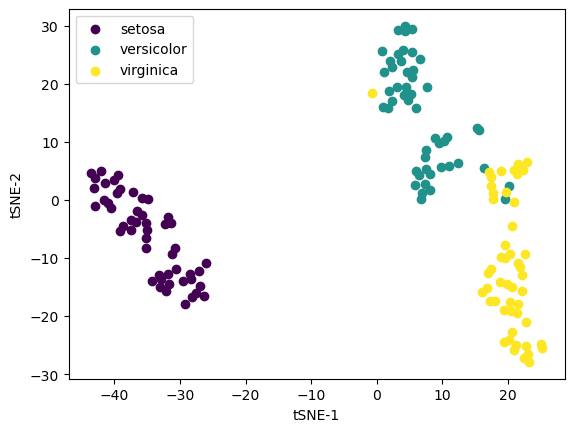

In [12]:
for label in iris['label'].unique():
    select = iris.label == label
    plt.scatter(X_tsne[select, 0], X_tsne[select, 1], label=label)

plt.xlabel('tSNE-1')
plt.ylabel('tSNE-2')
plt.legend(loc='upper left')
plt.show()

**Pregunta 5. Notas algunha diferenza entre as proxeccións de ambos algoritmos?**

Salta a la vista que las proyecciones no son iguales. Comparten una clara separación de la clase setosa pero hay dos diferencias claras. Lo primero es las escalas de los ejes, PCA mantiene una escala parecida a las variables originales mientras que t-SNE cambia a una escala más amplia de -40 a 20 que no tiene ninguna representación física real (son solo coordenadas para representar los clusters que el algoritmo inventó). La segunda diferencia notable es la forma de agrupación, donde t-SNE crea tres grupos más redondeados y con diferencia espacial más marcada mientras que PCA mantiene una visión más matemática que, al basarse en la varianza, no consigue separar tan bien las otras dos clases.

## Parte 2: Datos de moitas dimensións

Pasemos a un dataset máis complicado: o conxunto de díxitos do MNIST. Neste dataset as características representan a intensidade do pixel dunha imaxe de 28x28 que codifica un número do 0 ao 9 escrito a man.

In [13]:
digits = load_mnist()
digits

,0,1,2,3,4,5,6,7,8,9,...,776,777,778,779,780,781,782,783,target,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,5
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,4
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,2
69996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,3
69997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,4
69998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5,5


A interpretación destas características para nos é bastante opaca, e tan so adquire sentido cando a visualizamos como imaxe en forma de cuadrícula. A continuación podemos ver un exemplo para cada unha das etiquetas do dataset:

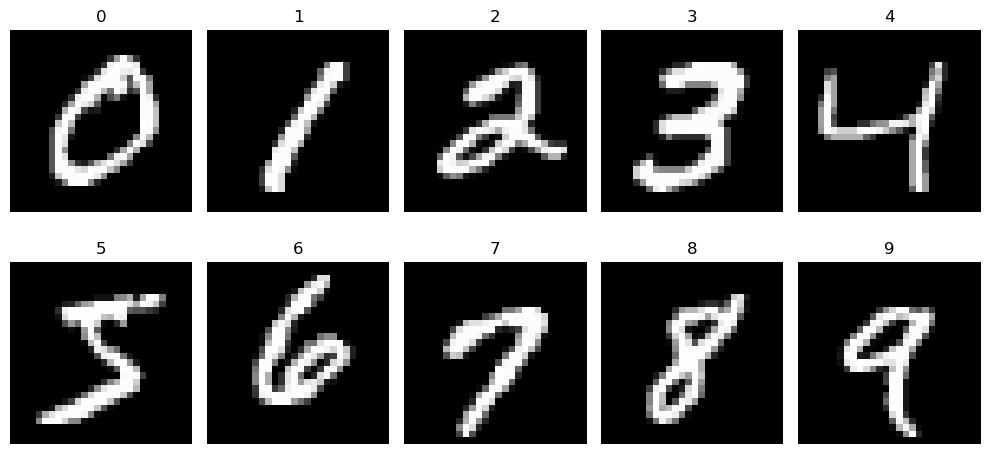

In [14]:
# Seleccionar un ejemplo por etiqueta
examples = digits.groupby('label').first()

# Visualizar los ejemplos
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.ravel()

PIXELS = 28

for i, (label, row) in enumerate(examples.iterrows()):
    img = row.iloc[:-1].values.reshape(PIXELS, PIXELS)  # Restaurar la imagen
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(label)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [15]:
sns.set_palette(colormaps['tab10'](np.linspace(0, 1, digits['label'].nunique())))

### 2.1. Limitacións de PCA

**Pregunta 6. Cantas compoñentes serían necesarias para capturar o 95% da variabilidade do dataset con PCA? Canta variabilidade explican entre as dúas primeiras compoñentes?**

In [16]:
pca_digits = PCA(random_state=42)
X_pca_digits = pca_digits.fit_transform(digits.drop(columns=['target', 'label']))

# Varianza explicada por cada componente
explained_variance = pca_digits.explained_variance_ratio_
ac_variance = np.cumsum(explained_variance)

#busco en el vector de varianza acumulada el número mínimo de componentes necesarias para explicar el 95% de la varianza
n_components_95 = np.argmax(ac_variance >= 0.95) + 1
n_components_95

154

In [17]:
ac_variance[1]

0.1690155724601664

Serían necesarias 154 componentes para explicar el 95% y entre las dos primeras solo explican el 16.9%.

**Pregunta 7. Visualiza en 2D o dataset. ¿Ten sentido o resultado atendendo aos valores anteriores?**

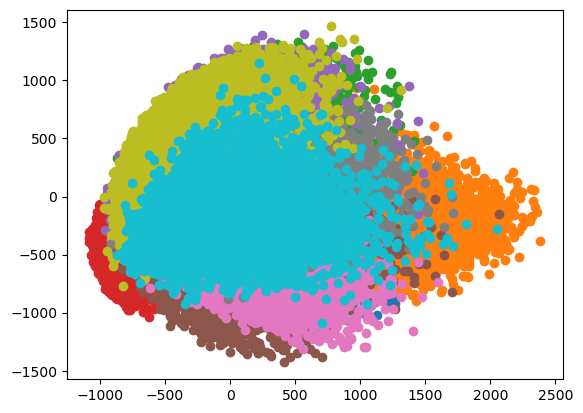

In [18]:
# Visualización en 2D 
for label in digits['label'].unique():
    select = digits.label == label
    plt.scatter(X_pca_digits[select, 0], X_pca_digits[select, 1], label=label)

El resultado tiene sentido, es una nube de puntos solapados donde no se entiende nada.

**Pregunta 8. Se tiveras que quedarte cun tamano de embedding para representar este conxunto de datos con PCA, de forma que o embedding resultante explique a maior parte da varianza dos datos de forma óptima (a maior representatividade do conxunto co menor tamano), con que valor te quedarías e por qué?**

In [19]:
# Suponiendo que quieres ver las 154 componentes que mencionaste
n_comps = 154
v_expl = PCA.explained_variance_ratio_[:n_comps]

plt.figure(figsize=(12, 5))
plt.bar(range(1, n_comps + 1), v_expl, alpha=0.7)

# LA CLAVE: Solo ponemos números cada 20 unidades
plt.xticks(np.arange(0, n_comps + 1, 20)) 

plt.title('Varianza por Componente (MNIST)')
plt.xlabel('Número de Componente Principal')
plt.ylabel('Varianza Explicada')
plt.show()

n_components_80 = np.argmax(ac_variance >= 0.80) + 1
n_components_80


KeyboardInterrupt



En un problema real se podría ajustar el número de componentes como un hiperparámetro e ir buscando según las métricas del modelo. Pero para este caso de ejemplo se podría ajustar teniendo en cuenta el codo (la gráfica superior indica aprox a partir de las 40 componentes) y a partir de ese rango buscar que se explique un 80% de la varianza por ejemplo. De esta forma nos quedaríamos con 43 componentes que explicarían el 80% reduciendo la dimensionalidad casi en un 90%.

### 2.2. Aplicando t-SNE

Empreguemos agora t-SNE para visualizar este conxunto de datos.

In [ ]:
X_tsne = TSNE(n_components=2, verbose=1, random_state=SEED).fit_transform(digits.drop(columns=['target', 'label']))

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 70000 samples in 0.045s...
[t-SNE] Computed neighbors for 70000 samples in 225.508s...
[t-SNE] Computed conditional probabilities for sample 1000 / 70000
[t-SNE] Computed conditional probabilities for sample 2000 / 70000
[t-SNE] Computed conditional probabilities for sample 3000 / 70000
[t-SNE] Computed conditional probabilities for sample 4000 / 70000
[t-SNE] Computed conditional probabilities for sample 5000 / 70000
[t-SNE] Computed conditional probabilities for sample 6000 / 70000
[t-SNE] Computed conditional probabilities for sample 7000 / 70000
[t-SNE] Computed conditional probabilities for sample 8000 / 70000
[t-SNE] Computed conditional probabilities for sample 9000 / 70000
[t-SNE] Computed conditional probabilities for sample 10000 / 70000
[t-SNE] Computed conditional probabilities for sample 11000 / 70000
[t-SNE] Computed conditional probabilities for sample 12000 / 70000
[t-SNE] Computed conditional probabilities for s

KeyboardInterrupt: 

In [ ]:
import plotly.express as px
import seaborn as sns
import pandas as pd

sns.set_palette(colormaps['tab10'](np.linspace(0, 1, digits['label'].nunique())))

# Crear un DataFrame para Plotly
df = pd.DataFrame({
    'id': digits.index,  # Usa los índices o asigna un identificador único a cada ejemplo
    'label': digits['label'],
    'tSNE-1': X_tsne[:, 0],
    'tSNE-2': X_tsne[:, 1],
})

# Crear el gráfico interactivo
fig = px.scatter(
    df, 
    x='tSNE-1', 
    y='tSNE-2', 
    color='label',
    hover_data=['id', 'label'],
    title='t-SNE Visualization with Hover Info',
    width=1200, 
    height=900
)

fig.update_traces(marker=dict(size=5, opacity=0.8))
fig.show()

**Pregunta 9. Compara esta visualización coa obtida por PCA. A que crees que é debida a diferenza?**

In [ ]:
## RESPOSTA

**Pregunta 10. Emprega a seguinte función para visualizar algúns dos exemplos que se atopan nunha rexión do espacio que non lles correspondería por etiqueta. Ten sentido que t-SNE os proxecte nesta rexión?**

In [ ]:
def show_sample(dataset, sample_id:int):

    example_row = dataset.iloc[sample_id]

    # Restaurar la imagen
    img = example_row.iloc[:-2].values.reshape(PIXELS, PIXELS)

    # Visualizar la imagen
    plt.imshow(img, cmap='gray')
    plt.title(f"Etiqueta: {example_row['label']:.0f}")
    plt.axis('off')
    plt.show()

In [ ]:
## RESPOSTA

## Parte 3: Comparativa de algoritmos

Nesta última parte vamos a facer uso de todo o aprendido para realizar unha comparación máis formal entre os distintos algoritmos e o impacto que os hiperparámetros poden ter no resultado obtido. Para isto empregaremos un novo dataset, o Fashion-MNIST, composto por imaxes representativas de distintos tipos de prendas de vestir.

In [20]:
fmnist = load_fmnist().iloc[0:5000]  ## nos quedamos solo con unha porción do dataset para maior rapidez de execución

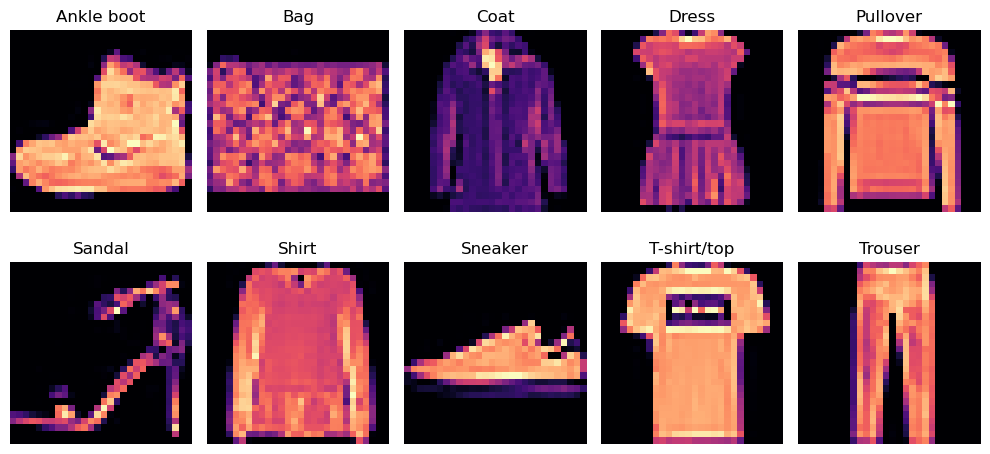

In [21]:
# Seleccionar un ejemplo por etiqueta
examples = fmnist.groupby('label').first()

# Visualizar los ejemplos
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.ravel()

for i, (label, row) in enumerate(examples.iterrows()):
    img = row.iloc[:-1].values.reshape(28, 28)  # Restaurar la imagen
    axes[i].imshow(img, cmap='magma')
    axes[i].set_title(label)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Nesta parte empregaremos un novo algoritmo que non empregamos antes no guión: UMAP. Este algoritmo require da instalación dunha [librería propia](https://umap-learn.readthedocs.io/en/latest/), polo que será preciso engadila ao noso entorno.

In [ ]:
!pip install umap-learn

In [22]:
from umap import UMAP

/home/lucas/miniconda3/envs/ApAutNosup/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 3.1. Análise de rendemento

In [23]:
import matplotlib as mpl
from matplotlib import cm
from matplotlib.lines import Line2D

def scatter_plot_all(results, labels=fmnist['target'].tolist(), titles=['PCA', 't-SNE', 'UMAP'],
                     class_names=fmnist.sort_values(by='target')['label'].unique().tolist()):
    
  cols = colormaps['tab10'](np.linspace(0, 1, len(class_names)))
  figsize = 6
  scale = 0.2
  num_plots = len(titles)
  fig, axs = plt.subplots(1, num_plots, figsize=(figsize * num_plots, figsize))
  colors = cols[labels]
  for index, (res, tit) in enumerate(zip(results, titles)):
    axs[index].scatter(res[:, 0], res[:, 1], c=colors, s=scale, alpha=0.8)
    axs[index].set_xticks([])
    axs[index].set_yticks([])
    axs[index].set_title(tit, fontsize=18)
    if (index == (num_plots - 1)):
      elements = []
      for label, name in enumerate(class_names):
        elements.append(Line2D(
            [0], [0], marker='o', lw=0, markersize=10,
            color=cols[label], label=name, alpha=0.8))
      axs[index].legend(handles=elements, fontsize=14, loc='center left', bbox_to_anchor=(1, 0.5))
    fig.tight_layout()

In [25]:
## COMPLETA O CÓDIGO  (lembra usar a mesma SEED)

data = fmnist.drop(columns=['label', 'target'])

pca2 = PCA(n_components=2, random_state=42)
tsne = TSNE(n_components=2, random_state=42, n_jobs=-1)
umap = UMAP(n_components=2, random_state=42, n_jobs=-1)

emb_pca = pca2.fit_transform(data)
emb_tsne = tsne.fit_transform(data)
emb_umap = umap.fit_transform(data)

/home/lucas/miniconda3/envs/ApAutNosup/lib/python3.8/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


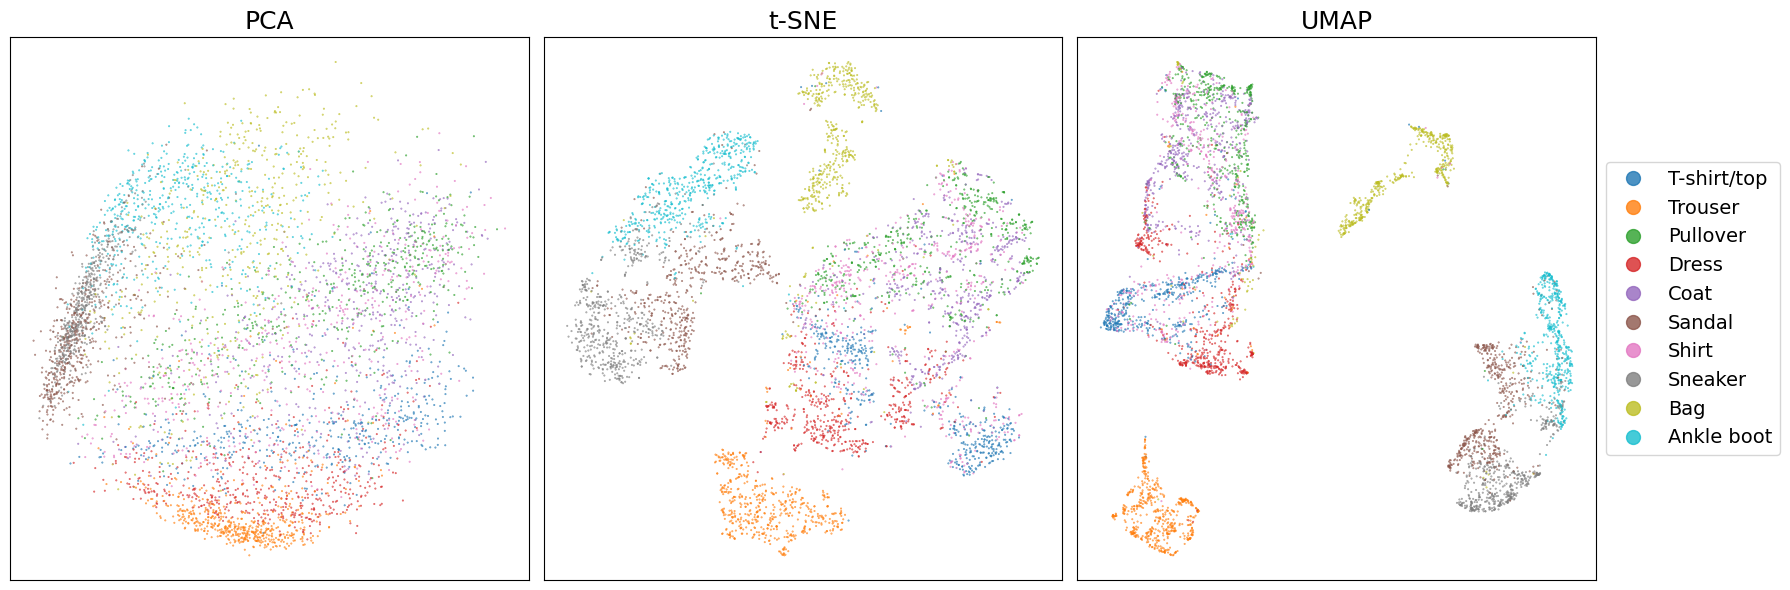

In [26]:
embeddings = [emb_pca, emb_tsne, emb_umap]

scatter_plot_all(embeddings)

**Pregunta 11. Fai unha análise dos resultados obtidos por cada cada algoritmo respecto da súa natureza e o seu tempo de execución.**

In [ ]:
## RESPOSTA

### 3.2. Efecto dos hiperparámetros

In [ ]:
perplexity = [5.0, 10.0, 30.0, 100.0]

f_mnist_results = []
for i,p in enumerate(perplexity):
  tsne = TSNE(n_components=2, verbose=1, perplexity=p, random_state=SEED)
  mnist_tsne = tsne.fit_transform(data)
  f_mnist_results.append(mnist_tsne)

titles = ['p = ' + str(t) for i,t in enumerate(perplexity)]
scatter_plot_all(f_mnist_results, titles=titles)

**Pregunta 12. Explica o efecto da `perplexity` en t-SNE.**

In [ ]:
## RESPOSTA

In [ ]:
neighbors = [3, 15, 30, 50, 100]
f_mnist_results_n = []

for i,n in enumerate(neighbors):
  reducer = UMAP(n_neighbors=n, min_dist=0.1, n_components=2,
                 metric='euclidean', random_state=SEED)
    
  reducer.fit(data)
  mnist_umap = reducer.transform(data)
  f_mnist_results_n.append(mnist_umap)

titles = ['k = ' + str(t) for i,t in enumerate(neighbors)]
scatter_plot_all(f_mnist_results_n, titles=titles)

In [ ]:
f_mnist_results_d = []
dists = [0.1, 0.3, 0.5, 0.7, 1]

for i,d in enumerate(dists):
  reducer = UMAP(n_neighbors=15, min_dist=d, n_components=2,
                 metric='euclidean', random_state=SEED)
    
  reducer.fit(data)
  mnist_umap = reducer.transform(data)
  f_mnist_results_d.append(mnist_umap)

titles = ['min_dist = ' + str(t) for i,t in enumerate(dists)]
scatter_plot_all(f_mnist_results_d, titles=titles)

**Pregunta 13. Que efecto teñen o número de veciños (`k`) e a distancia mínima (`min_dist`) en UMAP?** 

In [ ]:
## RESPOSTA

**Pregunta 14. Por que non se fai unha análise do impacto dos hiperparámetros en PCA?**

In [ ]:
## RESPOSTA

### 3.3. Aplicando o aprendido

Na páxina do [Embedding Projector](https://projector.tensorflow.org/) pódese visualizar o espazo de embedding dun conxunto de máis de 10K palabras, proxectadas tridimensionalmente cos distintos algoritmos vistos en clase, e modificar os seus parámetros de forma interactiva.

A ferramenta conta cun buscador de palabras que podes empregar para filtrar por un concepto concreto e consultar onde se dispoñen no espazo as palabras máis próximas semánticamente.

Tamén se pode cambiar o dataset a visualizar por outros dos empregados na práctica, como Iris ou MNIST. ***Recoméndase a visualización do espazo de imaxes de este último, proxectado cos distintos algoritmos, pola súa transparencia e interpretabilidade.***

**Pregunta 15. Acude á representación obtida por t-SNE ou UMAP, identifica algunha agrupación (clúster) que se teña formado de forma espontánea no espazo de proxección e argumenta a proximidade das palabras que a compoñen. Busca ti outra palabra diferente e compara, entre os diferentes algoritmos, a disposición de dita palabra no espazo de proxección en relación a (1) as palabras máis próximas segundo á distancia no espacio orixinal e (2) outras palabras colindantes a ela no espazo proxectado.**

******

In [ ]:
## RESPOSTA